In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
 
from sklearn.svm import SVC, SVR
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.utils.class_weight import compute_class_weight
import joblib
import pickle
import os

In [3]:
train_filename = "../data/training1109.xlsx"
save_dir="./dist"

## Read Data

In [4]:
def readExcel(filename, sheet_name="Sheet1", usecols=None):
    df=pd.read_excel(io=filename,sheet_name=sheet_name, usecols=usecols)
    nullIndexs = np.where((df.isnull()).values)
    return df.values, list(df.columns), nullIndexs


def getFeatures(values, headers, usedHeaders=None, dtype="float32"):
    if usedHeaders is None:
        return values
    usedHeaderIndexs = [headers.index(h) for h in usedHeaders]
    data = np.array(values[:,usedHeaderIndexs], dtype=dtype)
    return data

def getLabels(values, headers, labelHeader=None, dtype="int"):
    if labelHeader is None:
         raise Exception(f"必须指定labelHeader参数")
    labelHeaderIdx = headers.index(labelHeader)
    labels = np.array(values[:,labelHeaderIdx], dtype=dtype)
    return labels 

In [5]:
values, headers, nullIndexs = readExcel(train_filename)
rmRowIndexs = list(set(list(nullIndexs[0])))
print(len(rmRowIndexs))

128


In [6]:
all_labels = getLabels(values, headers, labelHeader="ssi.bin", dtype="int")
all_labels = np.delete(all_labels,rmRowIndexs,0)
print(all_labels.shape, all_labels.dtype)
print(all_labels)

(2369,) int64
[0 0 0 ... 0 0 0]


In [7]:
# 全部变量
usedHeaders = ["sex","age","height","weight","bmi","smoke",
               "hp","dm","chd","arrhy","copd","pad","rf","chemo",
               "radio","pn","picc","sbp.pre","dbp.pre","hr.pre",
               "plt.pre","plt.post","hb.pre","hb.post","alb.pre",
               "alb.post","tbil.pre","tbil.post","wbc.pre","wbc.post",
               "alt.pre","alt.post","scr.pre","scr.post","asa","bleed",
               "trans.surg","trans.post","icu","los.icu","scopy","open",
               "scopy.open","stoma","class.surg.t1"
              ]

# 筛选的连续变量
headers_1 = ["sex","age","height","weight","bmi","bleed","trans.surg","trans.post"]

# 筛选的分类变量
headers_2 = ["smoke","hp","dm","chd","arrhy","copd","pad",
             "rf","chemo","radio","pn","picc","asa","icu","los.icu",
             "scopy","open","scopy.open","stoma","class.surg.t1"
            ]
             
# 筛选的术前术后变量
headers_3 = ["sbp.pre","dbp.pre","hr.pre",
             "plt.pre","plt.post","hb.pre","hb.post","alb.pre",
             "alb.post","tbil.pre","tbil.post","wbc.pre","wbc.post",
             "alt.pre","alt.post","scr.pre","scr.post"
            ]

print(len(headers_1)+len(headers_2)+len(headers_3)==len(usedHeaders))

True


In [8]:
dtype = "float64"
all_features = getFeatures(values, headers, usedHeaders=usedHeaders, dtype=dtype)
all_features = np.delete(all_features,rmRowIndexs,0)
print(all_features.shape, all_features.dtype)
print(all_features)

(2369, 45) float64
[[ 1.   63.    1.59 ...  0.    0.    2.  ]
 [ 0.   21.    1.65 ...  0.    0.    3.  ]
 [ 1.   57.    1.78 ...  1.    0.    1.  ]
 ...
 [ 0.   59.    1.6  ...  0.    0.    1.  ]
 [ 0.   63.    1.58 ...  0.    0.    2.  ]
 [ 1.   58.    1.72 ...  0.    0.    2.  ]]


### 变量处理

In [9]:
"""
ctype:
  - both 取术前和术后
  - pre 只取术前
  - post 只取术后
  - rate 术后/术前
  - change 术后-术前
  - ratio (术后-术前)/术前 * 100
islog 是否取对数
"""
def calcPrePost(features, ctype="post", islog=False):
    pre = features[:,0]
    post = features[:,1]
    res=None
    if ctype=="both":
        res = np.empty((features.shape[0],2))
        res[:,0]=pre
        res[:,1]=post
    elif ctype=="pre":
        res = pre
        res = res.reshape((-1,1))
    elif ctype=="post":
        res = post
        res = res.reshape((-1,1))
    elif ctype=="rate":
        res = post/pre
        res = res.reshape((-1,1))
    elif ctype=="change":
        res = post-pre
        res = res.reshape((-1,1))
    elif ctype=="ratio":
        res = 100* (post-pre)/pre
        res = res.reshape((-1,1))
    else:
        res = features
    
    return np.log(res) if islog else res

In [10]:
var_one = [
    "copd",
    "pad",
    "picc",
    "icu",
    "los.icu",
    "scopy.open",
    "stoma",
    "class.surg.t1",
    {"key":"bleed","func":lambda fea: 1*(fea>500)},
    "weight"
]
var_pre_post = [
    {"pre":"wbc.pre","post":"wbc.post","ctype":"post","islog":True},
    {"pre":"plt.pre","post":"plt.post","ctype":"change","islog":False},
    {"pre":"hb.pre","post":"hb.post","ctype":"change","islog":False},
    {"pre":"alb.pre","post":"alb.post","ctype":"post","islog":False},
    {"pre":"alt.pre","post":"alt.post","ctype":"rate","islog":True},
    {"pre":"scr.pre","post":"scr.post","ctype":"rate","islog":False},
]

In [11]:
fea_1 = None
for pair in var_pre_post:
    fea = calcPrePost(
        all_features[:,[usedHeaders.index(pair["pre"]), usedHeaders.index(pair["post"])]], 
        ctype=pair["ctype"],
        islog=pair["islog"]
    )
    fea_1 = fea if fea_1 is None else np.concatenate([fea_1,fea],axis=1)

In [12]:
fea_2 = None
for key_func in var_one:
    if type(key_func)==str:
        fea = all_features[:,usedHeaders.index(key_func)].reshape((-1,1))
    else:
        key = key_func["key"]
        func = key_func["func"]
        fea = all_features[:,usedHeaders.index(key)]
        fea = func(fea).reshape((-1,1))
    fea_2 = fea if fea_2 is None else np.concatenate([fea_2,fea],axis=1)

## RVM Model

In [13]:
"""Relevance Vector Machine classes for regression and classification."""
import numpy as np
 
from scipy.optimize import minimize
from scipy.special import expit
 
from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin
from sklearn.metrics.pairwise import (
    linear_kernel,
    rbf_kernel,
    polynomial_kernel
)
from sklearn.multiclass import OneVsOneClassifier
from sklearn.utils.validation import check_X_y
from sklearn.utils.class_weight import compute_class_weight
 
class BaseRVM(BaseEstimator):
 
    """Base Relevance Vector Machine class.
    Implementation of Mike Tipping's Relevance Vector Machine using the
    scikit-learn API. Add a posterior over weights method and a predict
    in subclass to use for classification or regression.
    """
 
    def __init__(
        self,
        class_weight="balanced",
        kernel='rbf',
        degree=3,
        coef1=None,
        coef0=0.0,
        n_iter=3000,
        tol=1e-3,
        alpha=1e-6,
        threshold_alpha=1e9,
        beta=1.e-6,
        beta_fixed=False,
        bias_used=True,
        verbose=False
    ):
        """Copy params to object properties, no validation."""
        self.kernel = kernel
        self.degree = degree
        self.coef1 = coef1
        self.coef0 = coef0
        self.n_iter = n_iter
        self.tol = tol
        self.alpha = alpha
        self.threshold_alpha = threshold_alpha
        self.beta = beta
        self.beta_fixed = beta_fixed
        self.bias_used = bias_used
        self.verbose = verbose
        self.class_weight = class_weight
 
    def get_params(self, deep=True):
        """Return parameters as a dictionary."""
        params = {
            'kernel': self.kernel,
            'degree': self.degree,
            'coef1': self.coef1,
            'coef0': self.coef0,
            'n_iter': self.n_iter,
            'tol': self.tol,
            'alpha': self.alpha,
            'threshold_alpha': self.threshold_alpha,
            'beta': self.beta,
            'beta_fixed': self.beta_fixed,
            'bias_used': self.bias_used,
            'verbose': self.verbose,
            'class_weight': self.class_weight
        }
        return params
 
    def set_params(self, **parameters):
        """Set parameters using kwargs."""
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
 
    def _apply_kernel(self, x, y):
        """Apply the selected kernel function to the data."""
        if self.kernel == 'linear':
            phi = linear_kernel(x, y)
        elif self.kernel == 'rbf':
            phi = rbf_kernel(x, y, self.coef1)
        elif self.kernel == 'poly':
            phi = polynomial_kernel(x, y, self.degree, self.coef1, self.coef0)
        elif callable(self.kernel):
            phi = self.kernel(x, y)
            if len(phi.shape) != 2:
                raise ValueError(
                    "Custom kernel function did not return 2D matrix"
                )
            if phi.shape[0] != x.shape[0]:
                raise ValueError(
                    "Custom kernel function did not return matrix with rows"
                    " equal to number of data points."""
                )
        else:
            raise ValueError("Kernel selection is invalid.")
 
        if self.bias_used:
            phi = np.append(phi, np.ones((phi.shape[0], 1)), axis=1)
 
        return phi
 
    def _prune(self):
        """Remove basis functions based on alpha values."""
        keep_alpha = self.alpha_ < self.threshold_alpha
 
        if not np.any(keep_alpha):
            keep_alpha[0] = True
            if self.bias_used:
                keep_alpha[-1] = True
 
        if self.bias_used:
            if not keep_alpha[-1]:
                self.bias_used = False
            self.relevance_ = self.relevance_[keep_alpha[:-1]]
        else:
            self.relevance_ = self.relevance_[keep_alpha]
 
        self.alpha_ = self.alpha_[keep_alpha]
        self.alpha_old = self.alpha_old[keep_alpha]
        self.gamma = self.gamma[keep_alpha]
        self.phi = self.phi[:, keep_alpha]
        self.sigma_ = self.sigma_[np.ix_(keep_alpha, keep_alpha)]
        self.m_ = self.m_[keep_alpha]
 
    def fit(self, X, y):
        """Fit the RVR to the training data."""
        X, y = check_X_y(X, y)
 
        n_samples, n_features = X.shape
 
        self.phi = self._apply_kernel(X, X)
 
        n_basis_functions = self.phi.shape[1]
 
        self.relevance_ = X
        self.y = y
 
        self.alpha_ = self.alpha * np.ones(n_basis_functions)
        self.beta_ = self.beta
 
        self.m_ = np.zeros(n_basis_functions)
 
        self.alpha_old = self.alpha_
 
        for i in range(self.n_iter):
            self._posterior()
 
            self.gamma = 1 - self.alpha_*np.diag(self.sigma_)
            self.alpha_ = self.gamma/(self.m_ ** 2)
 
            if not self.beta_fixed:
                self.beta_ = (n_samples - np.sum(self.gamma))/(
                    np.sum((y - np.dot(self.phi, self.m_)) ** 2))
 
            self._prune()
 
            delta = np.amax(np.absolute(self.alpha_ - self.alpha_old))

            if self.verbose:
                print("Iteration: {}".format(i))
                # print("Alpha: {}".format(self.alpha_))
                # print("Beta: {}".format(self.beta_))
                # print("Gamma: {}".format(self.gamma))
                # print("m: {}".format(self.m_))
                print("delta: {}".format(delta))
                print("Relevance Vectors: {}".format(self.relevance_.shape[0]))
                print()
 
            if (delta < self.tol and i > 1) or self.relevance_.shape[0]<=1:
                break
 
            self.alpha_old = self.alpha_
 
        if self.bias_used:
            self.bias = self.m_[-1]
        else:
            self.bias = None
 
        return self
 
class RVR(BaseRVM, RegressorMixin):
 
    """Relevance Vector Machine Regression.
    Implementation of Mike Tipping's Relevance Vector Machine for regression
    using the scikit-learn API.
    """
 
    def _posterior(self):
        """Compute the posterior distriubtion over weights."""
        i_s = np.diag(self.alpha_) + self.beta_ * np.dot(self.phi.T, self.phi)
        self.sigma_ = np.linalg.inv(i_s)
        self.m_ = self.beta_ * np.dot(self.sigma_, np.dot(self.phi.T, self.y))
 
    def predict(self, X, eval_MSE=False):
        """Evaluate the RVR model at x."""
        phi = self._apply_kernel(X, self.relevance_)
 
        y = np.dot(phi, self.m_)
 
        if eval_MSE:
            MSE = (1/self.beta_) + np.dot(phi, np.dot(self.sigma_, phi.T))
            return y, MSE[:, 0]
        else:
            return y
 
 
class RVC(BaseRVM, ClassifierMixin):
 
    """Relevance Vector Machine Classification.
    Implementation of Mike Tipping's Relevance Vector Machine for
    classification using the scikit-learn API.
    """
 
    def __init__(self, n_iter_posterior=50, **kwargs):
        """Copy params to object properties, no validation."""
        self.n_iter_posterior = n_iter_posterior
        super(RVC, self).__init__(**kwargs)
 
    def get_params(self, deep=True):
        """Return parameters as a dictionary."""
        params = super(RVC, self).get_params(deep=deep)
        params['n_iter_posterior'] = self.n_iter_posterior
        return params
 
    def _classify(self, m, phi):
        return expit(np.dot(phi, m))
 
    def _log_posterior(self, m, alpha, phi, t):
 
        y = self._classify(m, phi)

        log_p = -1 * (self.w1*np.sum(np.log(y[t == 1]), 0) +
                      self.w2*np.sum(np.log(1-y[t == 0]), 0))
        log_p = log_p + 0.5*np.dot(m.T, np.dot(np.diag(alpha), m))

        c = (self.w1 * t- self.w2 * y + (self.w2-self.w1) * t * y)

        jacobian = np.dot(np.diag(alpha), m) - np.dot(phi.T, c)
 
        return log_p, jacobian
 
    def _hessian(self, m, alpha, phi, t):
        y = self._classify(m, phi)
        B = np.diag(-1 * (-self.w2 + (self.w2-self.w1) * t ) * y * (1-y))
        return np.diag(alpha) + np.dot(phi.T, np.dot(B, phi))
 
    def _posterior(self):
        result = minimize(
            fun=self._log_posterior,
            hess=self._hessian,
            x0=self.m_,
            args=(self.alpha_, self.phi, self.t),
            method='Newton-CG',
            jac=True,
            options={
                'maxiter': self.n_iter_posterior
            }
        )
 
        self.m_ = result.x
        self.sigma_ = np.linalg.inv(
            self._hessian(self.m_, self.alpha_, self.phi, self.t)
        )
 
    def fit(self, X, y):
        """Check target values and fit model."""
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        if type(self.class_weight)==str:
            self.weighting = compute_class_weight(self.class_weight, classes=self.classes_[::-1], y=y)
            self.weighting /= np.sum(self.weighting)  
        elif type(self.class_weight)==dict:
            self.weighting=[self.class_weight["1"], self.class_weight["0"]]  

        self.w1 = self.weighting[0]
        self.w2 = self.weighting[1]
        
        if n_classes < 2:
            raise ValueError("Need 2 or more classes.")
        elif n_classes == 2:
            self.t = np.zeros(y.shape)
            self.t[y == self.classes_[1]] = 1
            return super(RVC, self).fit(X, self.t)
        else:
            self.multi_ = None
            self.multi_ = OneVsOneClassifier(self)
            self.multi_.fit(X, y)
            return self
 
    def predict_proba(self, X):
        """Return an array of class probabilities."""
        phi = self._apply_kernel(X, self.relevance_)
        y = self._classify(self.m_, phi)
        return np.column_stack((1-y, y))
 
    def predict(self, X):
        """Return an array of classes for each input."""
        if len(self.classes_) == 2:
            y = self.predict_proba(X)
            res = np.empty(y.shape[0], dtype=self.classes_.dtype)
            res[y[:, 1] <= 0.5] = self.classes_[0]
            res[y[:, 1] >= 0.5] = self.classes_[1]
            return res
        else:
            return self.multi_.predict(X)

## Train

### Split Data

In [14]:
from sklearn.model_selection import train_test_split

test_size=0.3

all_selected_features = np.concatenate([fea_1,fea_2],axis=1)
train_features, test_features, train_labels, test_labels = train_test_split(all_selected_features, all_labels, 
                                                      test_size=test_size, random_state=123, stratify=all_labels)
print(train_features.shape, test_features.shape, train_labels.shape, test_labels.shape)

(1658, 16) (711, 16) (1658,) (711,)


In [15]:
scaler = StandardScaler()
scaler.fit(train_features)
train_features_s = scaler.transform(train_features)
test_features_s = scaler.transform(test_features)

In [21]:
pickle.dump(scaler, open(os.path.join(save_dir, 'scaler.pkl'),'wb'))

### SVC

C越大，即对分错样本的惩罚程度越大，因此在训练样本中准确率越高，但是泛化能力降低，也就是对测试数据的分类准确率降低。相反，减小C的话，容许训练样本中有一些误分类错误样本，泛化能力强

In [22]:
# 线性核函数
model_linear = SVC(kernel="linear", random_state=123, probability=True, class_weight="balanced", C=0.005)
model_linear.fit(train_features_s, train_labels)
print(model_linear.score(train_features_s, train_labels))

# 多项式核
model_poly=[]
degrees = [3,6]
C_s = [0.01,0.0005]
i=0
for d in degrees:
    _C = C_s[i] 
    model_poly_x = SVC(kernel="poly", degree=d, random_state=123, probability=True, class_weight="balanced",C=_C)
    model_poly_x.fit(train_features_s, train_labels)
    print(model_poly_x.score(train_features_s, train_labels))
    model_poly.append(model_poly_x)
    i+=1

# 径向核
model_rbf = SVC(kernel="rbf", random_state=123, probability=True, class_weight="balanced",C=0.05)
model_rbf.fit(train_features_s, train_labels)
print(model_rbf.score(train_features_s, train_labels))

# S核
model_sig = SVC(kernel="sigmoid",random_state=123, probability=True, class_weight="balanced",C=0.05)
model_sig.fit(train_features_s, train_labels)
print(model_sig.score(train_features_s, train_labels))

0.7346200241254524
0.8721351025331725
0.8799758745476478
0.6055488540410132
0.7171290711700844


0.26865671641791045
0.5650224215246636
0.36416184971098264
0.7346200241254524
0.5714285714285714
0.19730941704035873
0.2933333333333333
0.8721351025331725
0.9285714285714286
0.11659192825112108
0.20717131474103584
0.8799758745476478
0.21903520208604954
0.7533632286995515
0.3393939393939394
0.6055488540410132
0.254
0.5695067264573991
0.35131396957123096
0.7171290711700844


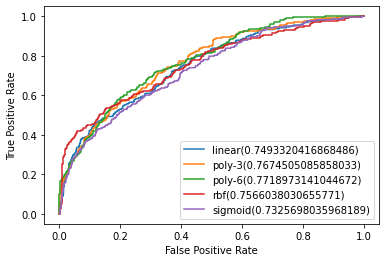

In [23]:
# Train Show
features = train_features_s
labels = train_labels
l_labels = [["linear"],[f"poly-{d}" for d in degrees],["rbf"], ["sigmoid"]]
model_list_list = [[model_linear],model_poly,[model_rbf],[model_sig]]
for i in range(len(model_list_list)):
    model_list = model_list_list[i]
    for j in range(len(model_list)):
        model = model_list[j]
        l_label = l_labels[i][j]
        predictions = model.predict(features)
        cm = confusion_matrix(labels, predictions, labels=model.classes_)

        print(precision_score(labels, predictions))
        print(recall_score(labels, predictions))
        print(f1_score(labels, predictions))
        print(accuracy_score(labels, predictions))

        scores = model.predict_proba(features)[:,1]

        score_roc_auc = roc_auc_score(labels, scores)
        fpr, tpr, thresholds = roc_curve(labels, scores)
        plt.plot(fpr, tpr, label=f'{l_label}({score_roc_auc})')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        
plt.legend()
plt.show()

0.28717948717948716
0.5894736842105263
0.3862068965517241
0.749648382559775
0.34285714285714286
0.12631578947368421
0.18461538461538463
0.8509142053445851
0.5714285714285714
0.042105263157894736
0.0784313725490196
0.8677918424753868
0.22188449848024316
0.7684210526315789
0.3443396226415094
0.6090014064697609
0.2714285714285714
0.6
0.37377049180327865
0.7313642756680732


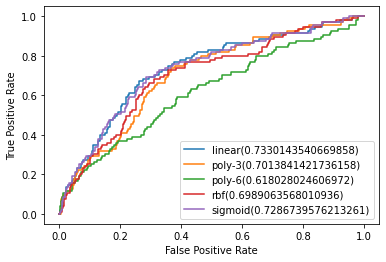

In [24]:
# Test Show
features = test_features_s
labels = test_labels
l_labels = [["linear"],[f"poly-{d}" for d in degrees],["rbf"], ["sigmoid"]]
model_list_list = [[model_linear],model_poly,[model_rbf],[model_sig]]
for i in range(len(model_list_list)):
    model_list = model_list_list[i]
    for j in range(len(model_list)):
        model = model_list[j]
        l_label = l_labels[i][j]
        predictions = model.predict(features)
        cm = confusion_matrix(labels, predictions, labels=model.classes_)

        print(precision_score(labels, predictions))
        print(recall_score(labels, predictions))
        print(f1_score(labels, predictions))
        print(accuracy_score(labels, predictions))

        scores = model.predict_proba(features)[:,1]

        score_roc_auc = roc_auc_score(labels, scores)
        fpr, tpr, thresholds = roc_curve(labels, scores)
        plt.plot(fpr, tpr, label=f'{l_label}({score_roc_auc})')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        
plt.legend()
plt.show()

In [26]:
joblib.dump(model_linear, os.path.join(save_dir,'model_svc_linear.model'))
joblib.dump(model_poly[0], os.path.join(save_dir,'model_svc_poly_3.model'))
joblib.dump(model_poly[1], os.path.join(save_dir,'model_svc_poly_6.model'))
joblib.dump(model_rbf, os.path.join(save_dir,'model_svc_rbf.model'))
joblib.dump(model_sig, os.path.join(save_dir,'model_svc_sig.model'))

['./dist/model_svc_sig.model']

**可以看到选出来的特征在 SVC 上表现并不好，都不如线性核的表现**

### LogisticRegression

In [27]:
from sklearn.linear_model import LogisticRegression
model_lg = LogisticRegression(solver='lbfgs', class_weight="balanced", random_state=123)
model_lg.fit(train_features_s, train_labels)
print(model_lg.score(train_features_s, train_labels))

0.6990349819059107


0.24909090909090909
0.6143497757847534
0.35446313065976714
0.6990349819059107
0.25
0.631578947368421
0.3582089552238806
0.6976090014064698


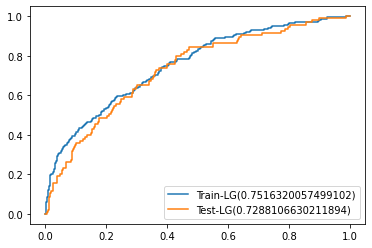

In [28]:
# Train show
features=train_features_s
labels=train_labels

predictions = model_lg.predict(features)
cm = confusion_matrix(labels, predictions, labels=model_lg.classes_)

print(precision_score(labels, predictions))
print(recall_score(labels, predictions))
print(f1_score(labels, predictions))
print(accuracy_score(labels, predictions))

scores = model_lg.predict_proba(features)[:,1]

score_roc_auc = roc_auc_score(labels, scores)
fpr, tpr, thresholds = roc_curve(labels, scores)
plt.plot(fpr, tpr, label=f'Train-LG({score_roc_auc})')

# Test show
features=test_features_s
labels=test_labels

predictions = model_lg.predict(features)
cm = confusion_matrix(labels, predictions, labels=model_lg.classes_)

print(precision_score(labels, predictions))
print(recall_score(labels, predictions))
print(f1_score(labels, predictions))
print(accuracy_score(labels, predictions))

scores = model_lg.predict_proba(features)[:,1]

score_roc_auc = roc_auc_score(labels, scores)
fpr, tpr, thresholds = roc_curve(labels, scores)
plt.plot(fpr, tpr, label=f'Test-LG({score_roc_auc})')

plt.legend()
plt.show()

In [29]:
joblib.dump(model_lg, os.path.join(save_dir, 'model_lg.model'))

['./dist/model_lg.model']

### RVC

In [ ]:
# 线性核函数
class_weight="balanced" 
model_rvc_linear = RVC(kernel="linear", class_weight=class_weight)
model_rvc_linear.fit(train_features_s, train_labels)
print(model_rvc_linear.score(train_features_s, train_labels))

# 多项式核
model_rvc_poly=[]
degrees = [3,6,9,12,15,18]
for d in degrees:
    model_rvc_poly_x = RVC(kernel="poly", degree=d, class_weight=class_weight)
    model_rvc_poly_x.fit(train_features_s, train_labels)
    print(model_rvc_poly_x.score(train_features_s, train_labels))
    model_rvc_poly.append(model_rvc_poly_x)

# 径向核  delta 增加，Relevance 减少
model_rvc_rbf = RVC(kernel="rbf", class_weight=class_weight, verbose=False, n_iter_posterior=10)
model_rvc_rbf.fit(train_features_s, train_labels)
print(model_rvc_rbf.score(train_features_s, train_labels))

In [34]:
joblib.dump(model_rvc_linear, os.path.join(save_dir,'model_rvc_linear.model'))
joblib.dump(model_rvc_rbf, os.path.join(save_dir,'model_rvc_rbf.model'))
for i in range(len(degrees)):
  joblib.dump(model_rvc_poly[i], os.path.join(save_dir, f'model_rvc_poly_{degrees[i]}.model'))

0.25
0.6547085201793722
0.3618339529120198
0.6893848009650181
0.15367483296213807
0.6188340807174888
0.24620874219446923
0.49034981905910735
0.1344993968636912
1.0
0.23710792131844763
0.1344993968636912
0.1344993968636912
1.0
0.23710792131844763
0.1344993968636912
0.11888111888111888
0.6098654708520179
0.19897585954645208
0.3395657418576598
0.12329749103942653
0.7713004484304933
0.2126081582200247
0.2316043425814234
0.1344993968636912
1.0
0.23710792131844763
0.1344993968636912
0.254606365159129
0.6816143497757847
0.37073170731707317
0.6887816646562123


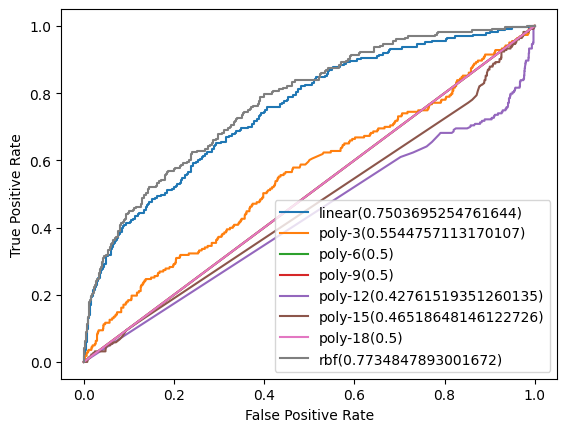

In [35]:
# Train Show
features = train_features_s
labels = train_labels

labels_rvc = [["linear"],[f"poly-{d}" for d in degrees],["rbf"]]
model_rvc_list_list = [[model_rvc_linear],model_rvc_poly,[model_rvc_rbf]]
for i in range(len(model_rvc_list_list)):
    model_list = model_rvc_list_list[i]
    for j in range(len(model_list)):
        model = model_list[j]
        l_label = labels_rvc[i][j]
        predictions = model.predict(features)
        cm = confusion_matrix(labels, predictions, labels=model.classes_)

        print(precision_score(labels, predictions))
        print(recall_score(labels, predictions))
        print(f1_score(labels, predictions))
        print(accuracy_score(labels, predictions))

        scores = model.predict_proba(features)[:,1]

        score_roc_auc = roc_auc_score(labels, scores)
        fpr, tpr, thresholds = roc_curve(labels, scores)
        plt.plot(fpr, tpr, label=f'{l_label}({score_roc_auc})')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        
plt.legend()
plt.show()

0.24193548387096775
0.631578947368421
0.3498542274052478
0.6863572433192686
0.16304347826086957
0.631578947368421
0.25917926565874727
0.5175808720112518
0.13361462728551335
1.0
0.2357320099255583
0.13361462728551335
0.13361462728551335
1.0
0.2357320099255583
0.13361462728551335
0.1228813559322034
0.6105263157894737
0.20458553791887127
0.3656821378340366
0.13245033112582782
0.8421052631578947
0.22889842632331905
0.2419127988748242
0.13361462728551335
1.0
0.2357320099255583
0.13361462728551335
0.24206349206349206
0.6421052631578947
0.35158501440922185
0.6835443037974683


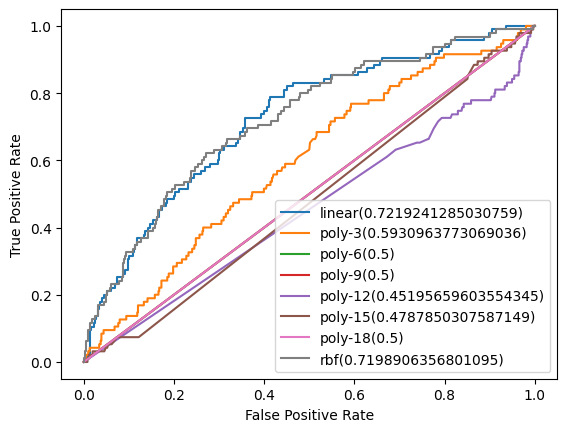

In [36]:
# Test Show
features = test_features_s
labels = test_labels

labels_rvc = [["linear"],[f"poly-{d}" for d in degrees],["rbf"]]
model_rvc_list_list = [[model_rvc_linear],model_rvc_poly,[model_rvc_rbf]]
for i in range(len(model_rvc_list_list)):
    model_list = model_rvc_list_list[i]
    for j in range(len(model_list)):
        model = model_list[j]
        l_label = labels_rvc[i][j]
        predictions = model.predict(features)
        cm = confusion_matrix(labels, predictions, labels=model.classes_)

        print(precision_score(labels, predictions))
        print(recall_score(labels, predictions))
        print(f1_score(labels, predictions))
        print(accuracy_score(labels, predictions))

        scores = model.predict_proba(features)[:,1]

        score_roc_auc = roc_auc_score(labels, scores)
        fpr, tpr, thresholds = roc_curve(labels, scores)
        plt.plot(fpr, tpr, label=f'{l_label}({score_roc_auc})')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        
plt.legend()
plt.show()

## Bset Contrast

In [90]:
best_model_list = [
    [model_linear,
    model_poly[0],
    model_poly[1]],
    
    [model_lg],
    
    [model_rvc_linear,
    model_rvc_poly[0],
    model_rvc_poly[4],
    model_rvc_rbf]
]
best_mode_labels = [
    ["linear",
    "poly_3",
    "poly_6"],
    ["logistic"],
    ["linear",
    "poly_3",
    "poly_15",
    "rbf"]
]

0.27309236947791166
0.5354330708661418
0.36170212765957455
0.7467018469656992
0.53125
0.20078740157480315
0.2914285714285714
0.8691292875989446
0.8529411764705882
0.1141732283464567
0.2013888888888889
0.8786279683377308
0.25878594249201275
0.6377952755905512
0.36818181818181817
0.7065963060686016
0.2511415525114155
0.6496062992125984
0.3622392974753018
0.6934036939313984
0.13817537643932684
0.6141732283464567
0.22559652928416485
0.43482849604221635
0.18944519621109607
0.5511811023622047
0.28197381671701915
0.6237467018469657
0.26851851851851855
0.6850393700787402
0.385809312638581
0.7076517150395778
0.2631578947368421
0.546875
0.3553299492385787
0.7320675105485233
0.47058823529411764
0.125
0.19753086419753085
0.8628691983122363
0.6666666666666666
0.0625
0.11428571428571428
0.869198312236287
0.2645161290322581
0.640625
0.37442922374429227
0.7109704641350211
0.25308641975308643
0.640625
0.3628318584070797
0.6962025316455697
0.1388888888888889
0.625
0.2272727272727273
0.42616033755274263


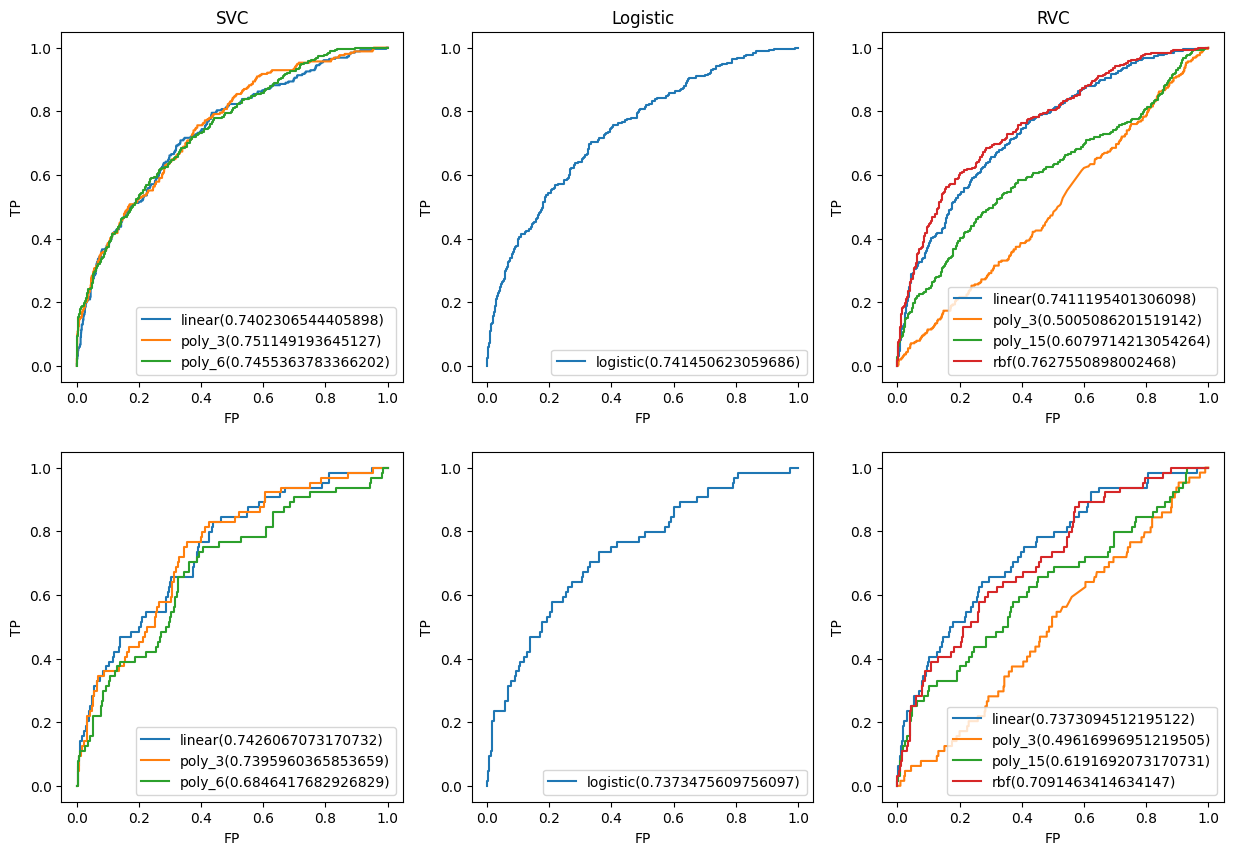

In [91]:
# Train Show
features = train_features_s
labels = train_labels
rows = 2
columns = len(best_model_list)
titles = ["SVC", "Logistic", "RVC"]
plt.figure(figsize=(columns*5,rows*5))
for i in range(len(best_model_list)):
    plt.subplot(rows,columns,i+1)
    plt.title(titles[i])
    model_list = best_model_list[i]
    for j in range(len(model_list)):
        model = model_list[j]
        l_label = best_mode_labels[i][j]
        predictions = model.predict(features)
        cm = confusion_matrix(labels, predictions, labels=model.classes_)

        print(precision_score(labels, predictions))
        print(recall_score(labels, predictions))
        print(f1_score(labels, predictions))
        print(accuracy_score(labels, predictions))

        scores = model.predict_proba(features)[:,1]

        score_roc_auc = roc_auc_score(labels, scores)
        fpr, tpr, thresholds = roc_curve(labels, scores)
        plt.plot(fpr, tpr, label=f'{l_label}({score_roc_auc})')
        plt.xlabel("FP")
        plt.ylabel("TP")
        plt.legend()


# Test Show
features = test_features_s
labels = test_labels
for i in range(len(best_model_list)):
    plt.subplot(rows,columns,i+1+columns)
    model_list = best_model_list[i]
    for j in range(len(model_list)):
        model = model_list[j]
        l_label = best_mode_labels[i][j]
        predictions = model.predict(features)
        cm = confusion_matrix(labels, predictions, labels=model.classes_)

        print(precision_score(labels, predictions))
        print(recall_score(labels, predictions))
        print(f1_score(labels, predictions))
        print(accuracy_score(labels, predictions))

        scores = model.predict_proba(features)[:,1]

        score_roc_auc = roc_auc_score(labels, scores)
        fpr, tpr, thresholds = roc_curve(labels, scores)
        plt.plot(fpr, tpr, label=f'{l_label}({score_roc_auc})')
        plt.xlabel("FP")
        plt.ylabel("TP")
        plt.legend()
        
# plt.show()
# plt.savefig("/kaggle/working/use_linear_selected_fea_best_model.jpg")

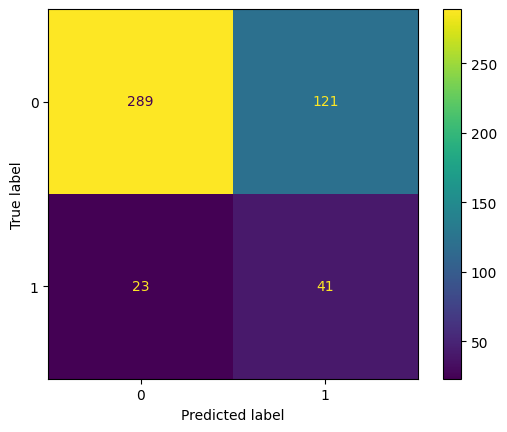

In [93]:
model = model_rvc_linear
predictions = model.predict(test_features_s)
cm = confusion_matrix(test_labels, predictions, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=model.classes_)
disp.plot()
plt.show()

In [30]:
!ls ./dist

model_lg.model		model_svc_poly_3.model	model_svc_rbf.model  scaler.pkl
model_svc_linear.model	model_svc_poly_6.model	model_svc_sig.model


In [39]:
!zip -r ./svm-svc-lr.zip ./dist/*

  adding: model_lg.model (deflated 29%)
  adding: model_rvc_linear.model (deflated 35%)
  adding: model_rvc_poly_12.model (deflated 64%)
  adding: model_rvc_poly_15.model (deflated 64%)
  adding: model_rvc_poly_18.model (deflated 64%)
  adding: model_rvc_poly_3.model (deflated 73%)
  adding: model_rvc_poly_6.model (deflated 73%)
  adding: model_rvc_poly_9.model (deflated 64%)
  adding: model_rvc_rbf.model (deflated 18%)
  adding: model_svc_linear.model (deflated 75%)
  adding: model_svc_poly_3.model (deflated 76%)
  adding: model_svc_poly_6.model (deflated 75%)
  adding: model_svc_rbf.model (deflated 75%)
  adding: model_svc_sig.model (deflated 75%)
  adding: scaler.pkl (deflated 12%)
